<a href="https://colab.research.google.com/github/jacobgreen4477/The-4th-ETRI-AI-Human-Understanding-Competition/blob/main/etri_baseline_v5_0_4(%EC%A6%9D%EA%B0%95).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📦 전처리 파일 불러오기
파일 from etri_baseline_v6_1_1.ipynb

In [4]:
# Core Libraries
import os
import sys
import json
import re
import ast
import glob
import random
from functools import reduce
from io import StringIO
from collections import Counter
from datetime import datetime, timedelta, time

# Numerical Operations
import numpy as np
import pandas as pd

# Math & Geospatial
from math import radians, cos, sin, asin, sqrt
from scipy.stats import entropy
from haversine import haversine

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, log_loss
from lightgbm import LGBMClassifier, log_evaluation, early_stopping
from xgboost import XGBClassifier
import lightgbm as lgb

# Deep Learning (PyTorch)
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torch.nn import functional as F

# Progress Tracking
from tqdm import tqdm
from tqdm.auto import tqdm
from category_encoders import TargetEncoder

# Warnings
import warnings
warnings.filterwarnings('ignore')

# seed 고정
SD = 42
random.seed(SD)
np.random.seed(SD)
os.environ['PYTHONHASHSEED'] = str(SD)

# pandas 옵션
pd.set_option('display.max_columns', 999)
pd.set_option('display.max_rows', 999)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%0.4f' % x)

In [5]:
train = pd.read_parquet(f"../data/train_without_valid.parquet")
valid = pd.read_parquet(f"../data/valid.parquet")

In [6]:
train = train.astype({"Q1": "int32", "Q2": "int32", "Q3": "int32", "S1": "int32", "S2": "int32", "S3": "int32"})
valid = valid.astype({"Q1": "int32", "Q2": "int32", "Q3": "int32", "S1": "int32", "S2": "int32", "S3": "int32"})

In [7]:
train.shape, valid.shape

((345, 162), (105, 162))

In [8]:
train.dtypes

subject_id                            object
sleep_date                            object
lifelog_date                          object
Q1                                     int32
Q2                                     int32
Q3                                     int32
S1                                     int32
S2                                     int32
S3                                     int32
charging_ratio                       float64
charging_sum                           int64
charging_transitions                   int64
avg_charging_duration                float64
max_charging_duration                  int64
all_WALKING_n_ETC_minutes              int64
all_VEHICLE_minutes                    int64
all_ACTIVITY_minutes                   int64
dawn_ACTIVITY_minutes                  int64
activehour_unique_label_count        float64
sleeptime_unique_label_count         float64
activehour_snor_count                float64
sleeptime_snor_count                 float64
ble_rssi_m

In [9]:
!python download_dataset.py --dataname adult
!python process_dataset.py --dataname adult

Start processing dataset adult from UCI.
Finish downloading dataset from https://archive.ics.uci.edu/static/public/2/adult.zip, data has been saved to data/adult.
Finish unzipping adult.
Start processing dataset default from UCI.
Traceback (most recent call last):
  File "/home/lhj/ws/etri/lhj/tabsyn/download_dataset.py", line 44, in <module>
    download_from_uci(name)
  File "/home/lhj/ws/etri/lhj/tabsyn/download_dataset.py", line 33, in download_from_uci
    request.urlretrieve(url, f'{save_dir}/{name}.zip')
  File "/usr/lib/python3.10/urllib/request.py", line 241, in urlretrieve
    with contextlib.closing(urlopen(url, data)) as fp:
  File "/usr/lib/python3.10/urllib/request.py", line 216, in urlopen
    return opener.open(url, data, timeout)
  File "/usr/lib/python3.10/urllib/request.py", line 519, in open
    response = self._open(req, data)
  File "/usr/lib/python3.10/urllib/request.py", line 536, in _open
    result = self._call_chain(self.handle_open, protocol, protocol +
  Fi

## 🥸 sample data 확인

In [7]:
x_cat_train = np.load("./data/adult/X_cat_train.npy", allow_pickle=True)
x_num_train = np.load("./data/adult/X_num_train.npy", allow_pickle=True)
y_train = np.load("./data/adult/y_train.npy", allow_pickle=True)

with open("./data/adult/info.json") as f:
    info = json.load(f)

In [8]:
x_cat_train.shape, x_cat_train[:2]

((32561, 8),
 array([[' State-gov', ' Bachelors', ' Never-married', ' Adm-clerical',
         ' Not-in-family', ' White', ' Male', ' United-States'],
        [' Self-emp-not-inc', ' Bachelors', ' Married-civ-spouse',
         ' Exec-managerial', ' Husband', ' White', ' Male',
         ' United-States']], dtype=object))

In [9]:
x_num_train.shape, x_num_train[:2]

((32561, 6),
 array([[3.9000e+01, 7.7516e+04, 1.3000e+01, 2.1740e+03, 0.0000e+00,
         4.0000e+01],
        [5.0000e+01, 8.3311e+04, 1.3000e+01, 0.0000e+00, 0.0000e+00,
         1.3000e+01]], dtype=float32))

In [10]:
y_train.shape, y_train[:2]

((32561, 1),
 array([[' <=50K'],
        [' <=50K']], dtype=object))

In [11]:
info.keys()
# 'name', 'task_type', 'header', 'column_names', 'num_col_idx', 'cat_col_idx', 'target_col_idx', 'file_type', 'data_path', 'test_path', 'column_info', 'train_num', 'test_num', 'idx_mapping', 'inverse_idx_mapping', 'idx_name_mapping', 'metadata'

# 필수 키
# task_type: binclass, multiclass 중 하나
# num_col_idx: 수치형 컬럼 인덱스 리스트
# cat_col_idx: 범주형 컬럼 인덱스 리스트

# target_col_idx: 생성할 타겟 컬럼 인덱스
# idx_mapping: 컬럼 인덱스와 컬럼 이름 매핑 딕셔너리
# n_classes: 클래스 개수

dict_keys(['name', 'task_type', 'header', 'column_names', 'num_col_idx', 'cat_col_idx', 'target_col_idx', 'file_type', 'data_path', 'test_path', 'column_info', 'train_num', 'test_num', 'idx_mapping', 'inverse_idx_mapping', 'idx_name_mapping', 'metadata'])

## 📦 우리 데이터 전처리 

In [ ]:
def make_tabsyn_data(df, result_dir="./data", train_ratio=0.6):
    targets_binary = ['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']

    df: pd.DataFrame = df.copy()
    x_data = df
    x_data = x_data.astype({
        'Q1': 'object', 'Q2': 'object', 'Q3': 'object',
        'S1': 'object', 'S2': 'object', 'S3': 'object'
    })

    # feature 분리
    column_names = x_data.columns.tolist()
    categorical_feature_cols = x_data.select_dtypes(include=['object']).columns.tolist()
    num_feature_cols = x_data.select_dtypes(exclude=['object']).columns.tolist()

    x_cat = x_data[categorical_feature_cols].values
    x_num = x_data[num_feature_cols].values

    # 1. 먼저 비율대로 split
    idx = np.arange(df.shape[0])
    train_size = int(train_ratio * df.shape[0])
    np.random.shuffle(idx)
    train_idx = idx[:train_size]
    test_idx = idx[train_size:]
    train_idx_set = set(train_idx)

    # 2. 카테고리별 최소 1개 보장
    cat_uniques = {col: set(x_data[col].unique()) for col in categorical_feature_cols}
    for col in categorical_feature_cols:
        for val in cat_uniques[col]:
            idxs = set(x_data.index[x_data[col] == val])
            if len(idxs) == 0:
                continue  # 값이 실제로 없음
            if not idxs & train_idx_set:
                train_idx_set.add(next(iter(idxs)))

    # 3. train/test 재계산
    train_idx = np.array(sorted(train_idx_set))
    test_idx = np.array([i for i in range(len(x_data)) if i not in train_idx_set])

    print(f"train 개수: {len(train_idx)}, test 개수: {len(test_idx)}")

    x_cat_train = x_cat[train_idx]
    x_cat_test = x_cat[test_idx]
    x_num_train = x_num[train_idx]
    x_num_test = x_num[test_idx]

    num_col_idx = [column_names.index(col) for col in num_feature_cols]
    cat_col_idx = [column_names.index(col) for col in categorical_feature_cols]

    dataset_name = "etri_syn"
    data_dir = os.path.join(result_dir, dataset_name)
    os.makedirs(data_dir, exist_ok=True)

    idx_mapping = {}

    curr_num_idx = 0
    curr_cat_idx = len(num_col_idx)
    curr_target_idx = curr_cat_idx + len(cat_col_idx)

    for idx in range(len(column_names + [dataset_name])):

        if idx in num_col_idx:
            idx_mapping[int(idx)] = curr_num_idx
            curr_num_idx += 1
        elif idx in cat_col_idx:
            idx_mapping[int(idx)] = curr_cat_idx
            curr_cat_idx += 1
        else:
            idx_mapping[int(idx)] = curr_target_idx
            curr_target_idx += 1

    np.save(os.path.join(data_dir, "X_cat_train.npy"), x_cat_train)
    np.save(os.path.join(data_dir, "X_cat_test.npy"), x_cat_test)
    np.save(os.path.join(data_dir, "X_num_train.npy"), x_num_train)
    np.save(os.path.join(data_dir, "X_num_test.npy"), x_num_test)
    # np.save(os.path.join(data_dir, "y_train.npy"), y_data.iloc[train_idx][target_col].values)
    # np.save(os.path.join(data_dir, "y_test.npy"), y_data.iloc[test_idx][target_col].values)
    np.save(os.path.join(data_dir, "y_train.npy"), np.zeros(len(train_idx), dtype=int))
    np.save(os.path.join(data_dir, "y_test.npy"), np.zeros(len(test_idx), dtype=int))
    with open(os.path.join(data_dir, "info.json"), "w") as f:
        json.dump({
            "name": dataset_name,
            "task_type": "multiclass",
            "n_classes": 2,
            "header": None,
            "column_names": column_names + [dataset_name],
            "num_col_idx": [column_names.index(col) for col in num_feature_cols],
            "cat_col_idx": [column_names.index(col) for col in categorical_feature_cols],
            "target_col_idx": [len(column_names)],
            "file_type": "npy",
            "data_path": os.path.join(data_dir, "X_cat_train.npy"),
            "test_path": os.path.join(data_dir, "X_cat_test.npy"),
            "column_info": {col: str(x_data[col].dtype) for col in column_names},
            "train_num": len(train_idx),
            "test_num": len(test_idx),
            "idx_mapping": idx_mapping,
            "inverse_idx_mapping": {v: k for k, v in idx_mapping.items()},
            "idx_name_mapping": {str(i): name for i, name in enumerate(column_names + [dataset_name])},
            "metadata": {
                "columns": {
                    str(i): {
                        "sdtype": "numerical" if col in num_feature_cols else "categorical"
                    } for i, col in enumerate(column_names)
                }
            }
        }, f, indent=4)

In [ ]:
# train 을 split
# make_tabsyn_data(train, train_ratio=0.8)

train 개수: 296, test 개수: 49


In [10]:
def make_tabsyn_data_v2(train_df, test_df, result_dir="./data"):
    train_df = train_df.astype({
        'Q1': 'object', 'Q2': 'object', 'Q3': 'object',
        'S1': 'object', 'S2': 'object', 'S3': 'object'
    })
    test_df = test_df.astype(train_df.dtypes.to_dict())
    assert train_df.shape[1] == test_df.shape[1], "Train and test data must have the same number of columns."

    # feature 분리
    column_names = train_df.columns.tolist()
    categorical_feature_cols = train_df.select_dtypes(include=['object']).columns.tolist()
    num_feature_cols = train_df.select_dtypes(exclude=['object']).columns.tolist()

    x_cat_train = train_df[categorical_feature_cols].values
    x_cat_test = test_df[categorical_feature_cols].values
    x_num_train = train_df[num_feature_cols].values
    x_num_test = test_df[num_feature_cols].values

    num_col_idx = [column_names.index(col) for col in num_feature_cols]
    cat_col_idx = [column_names.index(col) for col in categorical_feature_cols]

    dataset_name = "etri_syn"
    data_dir = os.path.join(result_dir, dataset_name)
    os.makedirs(data_dir, exist_ok=True)

    idx_mapping = {}

    curr_num_idx = 0
    curr_cat_idx = len(num_col_idx)
    curr_target_idx = curr_cat_idx + len(cat_col_idx)

    for idx in range(len(column_names + [dataset_name])):

        if idx in num_col_idx:
            idx_mapping[int(idx)] = curr_num_idx
            curr_num_idx += 1
        elif idx in cat_col_idx:
            idx_mapping[int(idx)] = curr_cat_idx
            curr_cat_idx += 1
        else:
            idx_mapping[int(idx)] = curr_target_idx
            curr_target_idx += 1

    assert x_cat_train.shape[1] == x_cat_test.shape[1], "Categorical features must match between train and test."
    assert x_num_train.shape[1] == x_num_test.shape[1], "Numerical features must match between train and test."

    np.save(os.path.join(data_dir, "X_cat_train.npy"), x_cat_train)
    np.save(os.path.join(data_dir, "X_cat_test.npy"), x_cat_test)
    np.save(os.path.join(data_dir, "X_num_train.npy"), x_num_train)
    np.save(os.path.join(data_dir, "X_num_test.npy"), x_num_test)
    # np.save(os.path.join(data_dir, "y_train.npy"), y_data.iloc[train_idx][target_col].values)
    # np.save(os.path.join(data_dir, "y_test.npy"), y_data.iloc[test_idx][target_col].values)
    np.save(os.path.join(data_dir, "y_train.npy"), np.zeros(len(train_df), dtype=int))
    np.save(os.path.join(data_dir, "y_test.npy"), np.zeros(len(test_df), dtype=int))
    with open(os.path.join(data_dir, "info.json"), "w") as f:
        json.dump({
            "name": dataset_name,
            "task_type": "multiclass",
            "n_classes": 2,
            "header": None,
            "column_names": column_names + [dataset_name],
            "num_col_idx": [column_names.index(col) for col in num_feature_cols],
            "cat_col_idx": [column_names.index(col) for col in categorical_feature_cols],
            "target_col_idx": [len(column_names)],
            "file_type": "npy",
            "data_path": os.path.join(data_dir, "X_cat_train.npy"),
            "test_path": os.path.join(data_dir, "X_cat_test.npy"),
            "column_info": {col: str(train_df[col].dtype) for col in column_names},
            "train_num": len(train_df),
            "test_num": len(test_df),
            "idx_mapping": idx_mapping,
            "inverse_idx_mapping": {v: k for k, v in idx_mapping.items()},
            "idx_name_mapping": {str(i): name for i, name in enumerate(column_names + [dataset_name])},
            "metadata": {
                "columns": {
                    str(i): {
                        "sdtype": "numerical" if col in num_feature_cols else "categorical"
                    } for i, col in enumerate(column_names)
                }
            }
        }, f, indent=4)

In [12]:
make_tabsyn_data_v2(train, valid, result_dir="./data")

### 📦 Tabsyn 학습
- 비고
  - vae epoch 4000 -> 4000 (`tabsyn/vae/main.py` 118 번 줄)
  - tabsyn epoch 10001 -> 10001 (`tabsyn/tabsyn/main.py` 44 번 줄)
  - 생성 갯수 조정 파라미터 추가 (`tabsyn/utils.py` 120 번 줄)


In [1]:
import torch
torch.cuda.is_available()

True

In [ ]:
%run main.py --method vae  --dataname etri_syn

Using device: cuda:0


RuntimeError: CUDA error: device-side assert triggered
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [1]:
%run main.py --method tabsyn --dataname etri_syn

Using device: cuda:0
/home/lhj/ws/etri/lhj/tabsyn/tabsyn/ckpt/etri_syn/
MLPDiffusion(
  (proj): Linear(in_features=652, out_features=1024, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=1024, out_features=2048, bias=True)
    (1): SiLU()
    (2): Linear(in_features=2048, out_features=2048, bias=True)
    (3): SiLU()
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): SiLU()
    (6): Linear(in_features=1024, out_features=652, bias=True)
  )
  (map_noise): PositionalEmbedding()
  (time_embed): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): SiLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
  )
)
the number of parameters 11829900


Epoch 2/2: 100%|██████████| 1/1 [00:00<00:00, 19.84it/s, Loss=2.41]

Time:  0.2199246883392334


In [15]:
!mkdir -p ./synthetic/
%run main.py --method tabsyn --dataname etri_syn --mode sample --save_path ./synthetic/etri_syn.csv --num_samples 1000


Using device: cuda:0
Generating 1000 samples...
(1000, 13)
Time: 0.518031120300293
Saving sampled data to ./synthetic/etri_syn.csv


In [16]:
train.shape, train.dtypes

((345, 162),
 subject_id                            object
 sleep_date                            object
 lifelog_date                          object
 Q1                                     int64
 Q2                                     int64
 Q3                                     int64
 S1                                     int64
 S2                                     int64
 S3                                     int64
 charging_ratio                       float64
 charging_sum                           int64
 charging_transitions                   int64
 avg_charging_duration                float64
 max_charging_duration                  int64
 all_WALKING_n_ETC_minutes              int64
 all_VEHICLE_minutes                    int64
 all_ACTIVITY_minutes                   int64
 dawn_ACTIVITY_minutes                  int64
 activehour_unique_label_count        float64
 sleeptime_unique_label_count         float64
 activehour_snor_count                float64
 sleeptime_snor_count

In [17]:
ori_syn_df = pd.read_csv("./synthetic/etri_syn.csv")

In [18]:
def sync_df(df, dtypes: dict):
    df = df.copy()
    for col, dtype in dtypes.items():
        if col in df.columns:
            df[col] = df[col].astype(dtype)
        else:
            print(f"Warning: Column {col} not found in DataFrame.")
            df[col] = pd.Series(
                data=0 if dtype in [np.int64, np.float64] else '',
                dtype=dtype,
            )  # Add missing column with correct dtype
    
    dummy = set(df.columns) - set(dtypes.keys())
    if dummy:
        print(f"Warning: Extra columns {dummy} found in DataFrame. They will be dropped.")
        df = df.drop(columns=dummy)

    return df


In [19]:
syn_df = sync_df(ori_syn_df, train.dtypes.to_dict())

In [20]:
syn_df.shape[1] == train.shape[1], syn_df.dtypes.equals(train.dtypes)

(True, True)

## 생성된 데이터의 상관계수가 train, val 과 같아야하지 않을까?

In [35]:
num_cols = train.select_dtypes(include=[np.number]).columns

train_corr = train[num_cols].corr()
valid_corr = valid[num_cols].corr()
syn_corr = syn_df[num_cols].corr()

In [49]:
def corr_diff_sum(corr1, corr2):
    """
    두 상관계수 행렬(corr1, corr2)의 차이(절대값 기준)를 반환합니다.
    corr1, corr2: pd.DataFrame (동일한 컬럼 순서/이름)
    반환값: pd.DataFrame (차이 행렬)
    """
    # 공통 컬럼만 사용
    common_cols = corr1.columns.intersection(corr2.columns)
    diff = (corr1.loc[common_cols, common_cols] - corr2.loc[common_cols, common_cols]).abs()
    return diff.sum().sum()

In [50]:
print(f"Train vs Valid Correlation Difference:\n{corr_diff_sum(train_corr, valid_corr)}")
print(f"Train vs Synthetic Correlation Difference:\n{corr_diff_sum(train_corr, syn_corr)}")
print(f"Valid vs Synthetic Correlation Difference:\n{corr_diff_sum(valid_corr, syn_corr)}")

Train vs Valid Correlation Difference:
2515.2666186843117
Train vs Synthetic Correlation Difference:
2408.8282754275633
Valid vs Synthetic Correlation Difference:
2908.737066101521


In [44]:
def vis_corr(corr):
    # 시각화
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=False, cmap="coolwarm", square=True)
    plt.title("Correlation Matrix of Numerical Columns in df")
    plt.show()

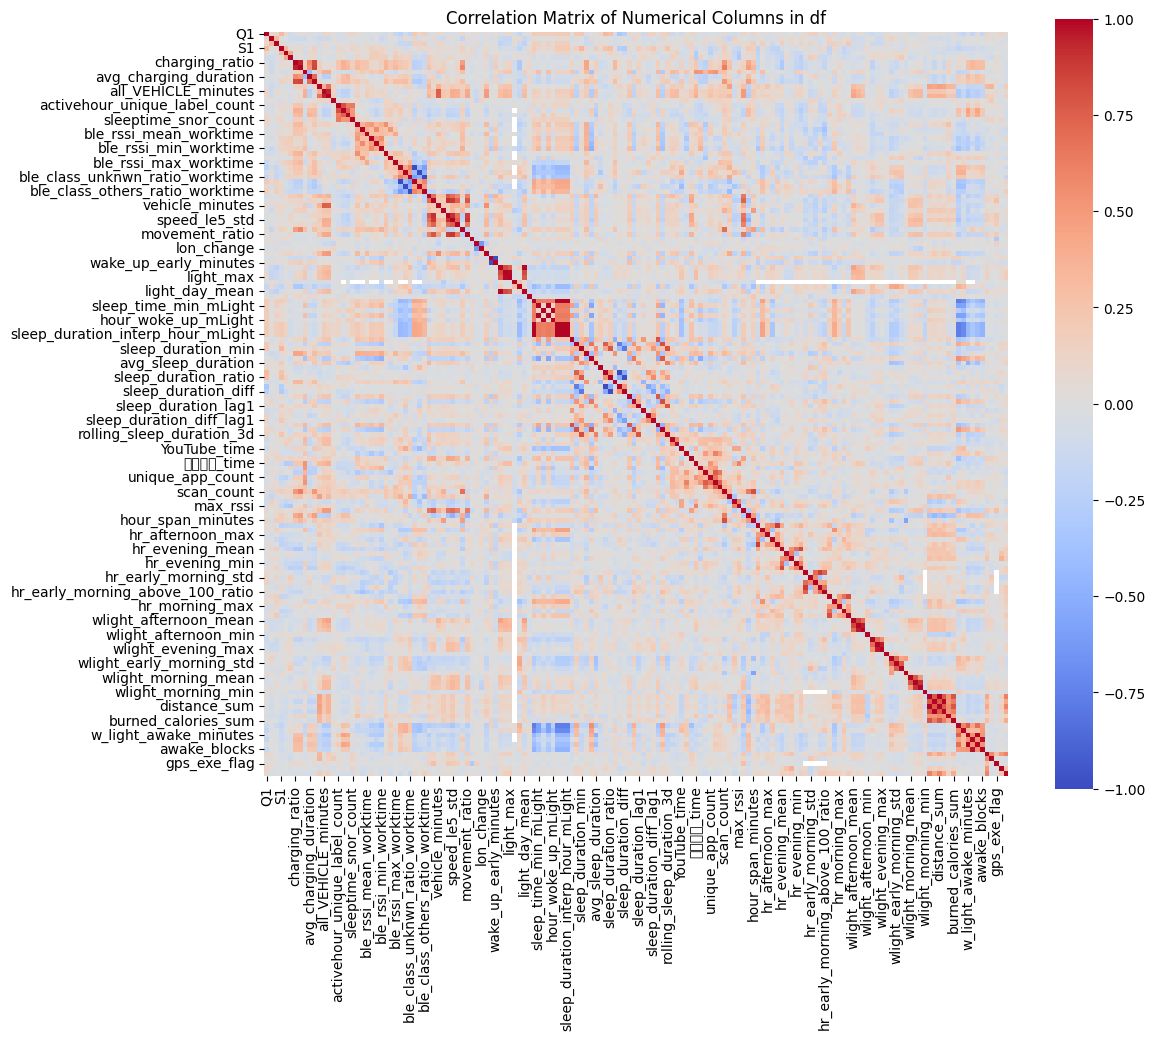

In [45]:
vis_corr(train_corr)

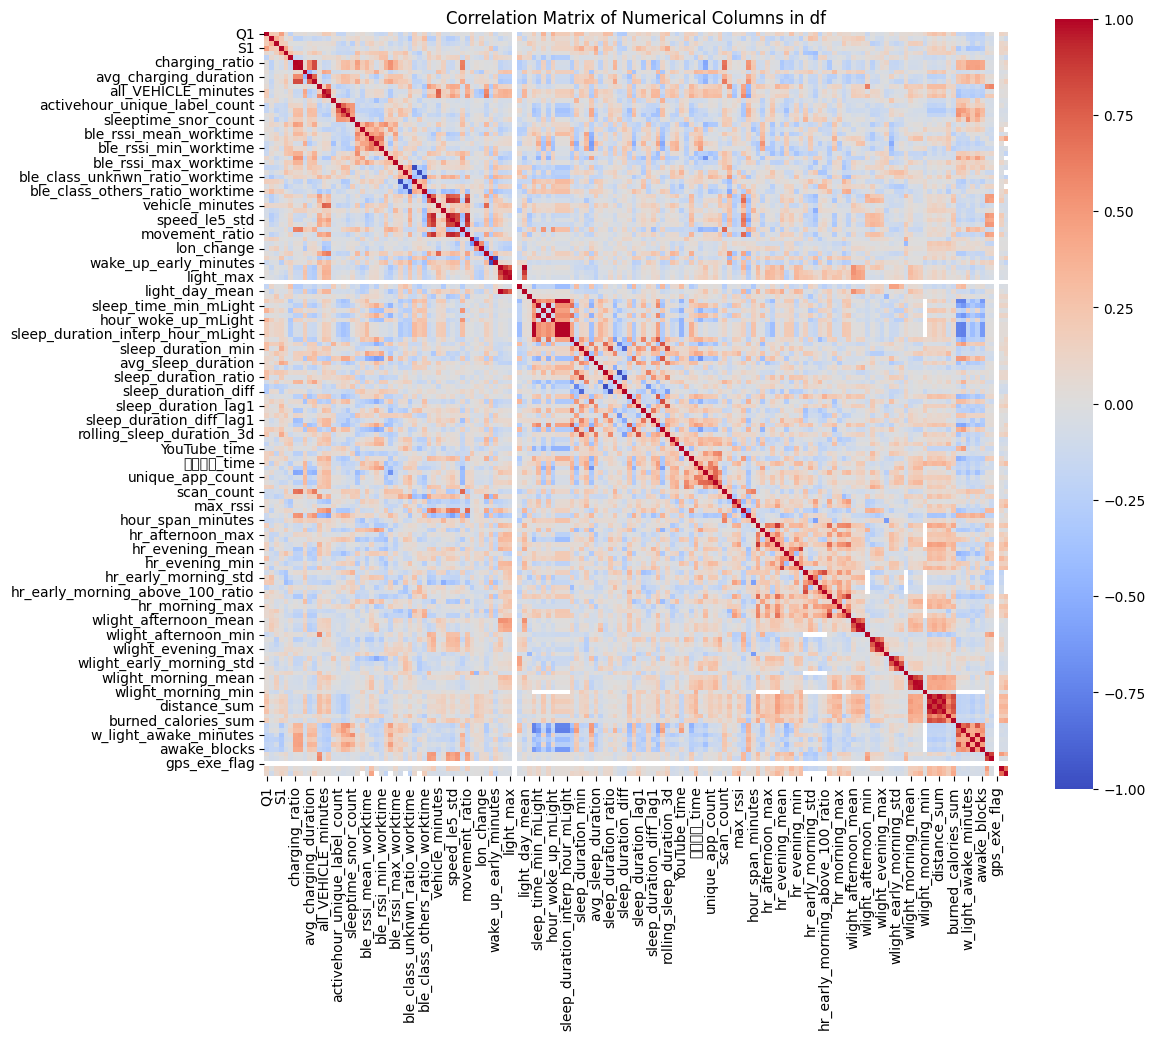

In [46]:
vis_corr(valid_corr)

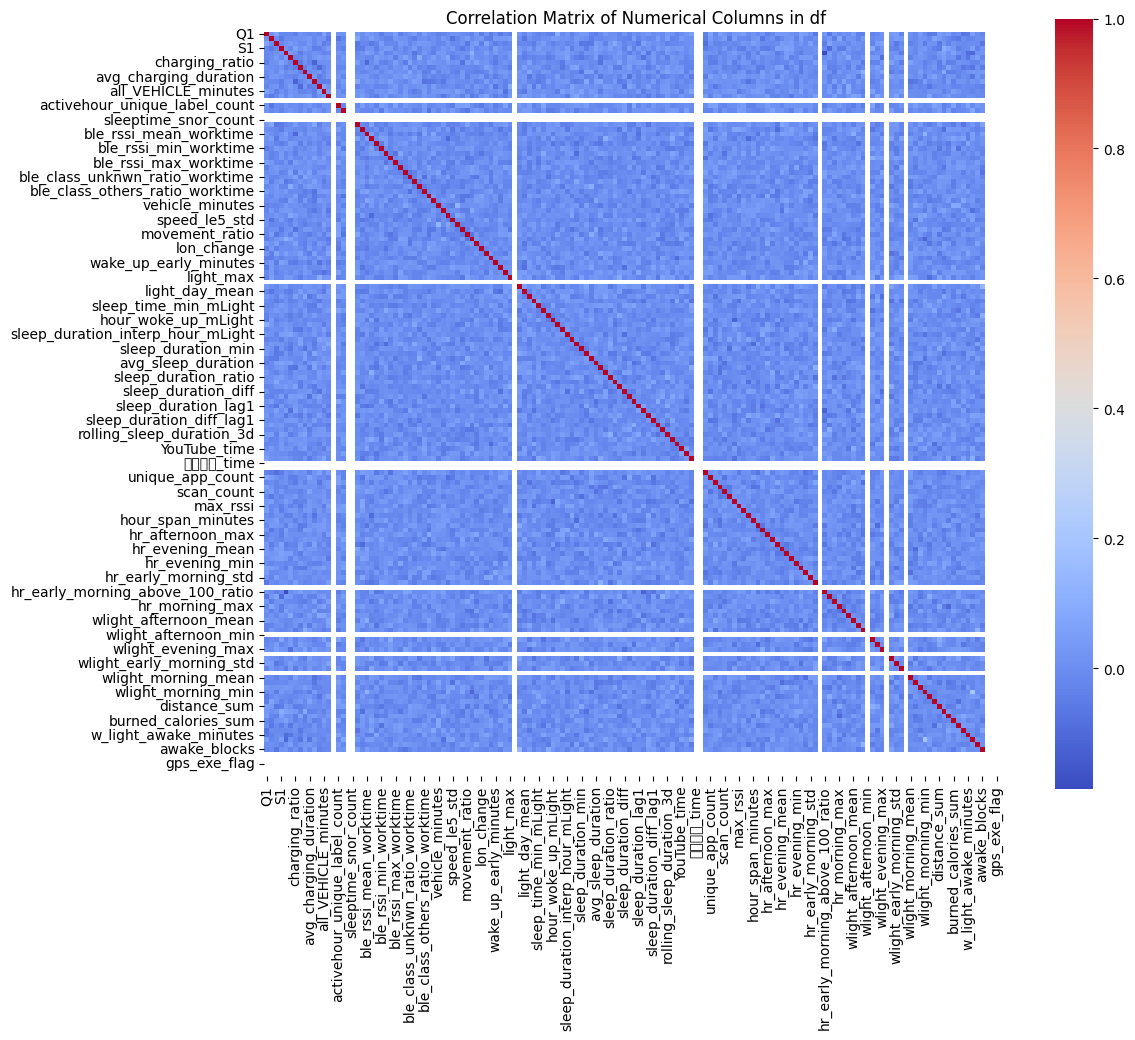

In [48]:
vis_corr(syn_corr)

### 🔥 추정수면효율
- 추정수면효율 (S2) : (불끈 시간 - 핸드폰 이용한 마지막 시간) / 추정수면시간

In [40]:
train = pd.read_parquet(f"../data/train_0524_v1.parquet")
test = pd.read_parquet(f"../data/test_0524_v1.parquet")
syn = syn_df.copy()

In [29]:
def calculate_sleep_duration_min(sleep_time, wake_time):
    """
    취침 시각(sleep_time)과 기상 시각(wake_time)을 입력받아 수면 시간(분) 반환
    단위는 float 시간 (예: 23.5, 6.25)
    """
    if pd.isna(sleep_time) or pd.isna(wake_time):
        return None
    if wake_time < sleep_time:
        wake_time += 24  # 자정 넘긴 경우 보정
    duration = (wake_time - sleep_time) * 60
    return round(duration)

In [41]:
train['불끈시간부터기상시간'] = train.apply(lambda x: calculate_sleep_duration_min(x['lights_off_time'],x['wake_time']),axis=1)
test['불끈시간부터기상시간'] = test.apply(lambda x: calculate_sleep_duration_min(x['lights_off_time'],x['wake_time']),axis=1)
syn['불끈시간부터기상시간'] = syn.apply(lambda x: calculate_sleep_duration_min(x['lights_off_time'],x['wake_time']),axis=1)

In [42]:
train['추정수면효율'] = train['불끈시간부터기상시간']/train['sleep_duration_min']
test['추정수면효율'] = test['불끈시간부터기상시간']/test['sleep_duration_min']
syn['추정수면효율'] = syn['불끈시간부터기상시간']/syn['sleep_duration_min']

# 이상값 제거
train['추정수면효율'] = np.where(train['추정수면효율']<-5,np.nan,train['추정수면효율'])
test['추정수면효율'] = np.where(test['추정수면효율']<-5,np.nan,test['추정수면효율'])
syn['추정수면효율'] = np.where(syn['추정수면효율']<-5,np.nan,syn['추정수면효율'])
train['추정수면효율'] = np.where(train['추정수면효율']>5,np.nan,train['추정수면효율'])
test['추정수면효율'] = np.where(test['추정수면효율']>55,np.nan,test['추정수면효율'])
syn['추정수면효율'] = np.where(syn['추정수면효율']>5,np.nan,syn['추정수면효율'])

In [43]:
# sleep duration

train['sleep_time_m_light_sleep_time'] = train['sleep_time'] - train['light_sleep_time']
test['sleep_time_m_light_sleep_time'] = test['sleep_time'] - test['light_sleep_time']
syn['sleep_time_m_light_sleep_time'] = syn['sleep_time'] - syn['light_sleep_time']

train['wake__time_m_light_wake__time'] = train['wake_time'] - train['light_wake_time']
test['wake__time_m_light_wake__time'] = test['wake_time'] - test['light_wake_time']
syn['wake__time_m_light_wake__time'] = syn['wake_time'] - syn['light_wake_time']

train['sleep_duration_min_m_light_sleep_duration_min'] = train['sleep_duration_min'] - train['light_sleep_duration_min']
test['sleep_duration_min_m_light_sleep_duration_min'] = test['sleep_duration_min'] - test['light_sleep_duration_min']
syn['sleep_duration_min_m_light_sleep_duration_min'] = syn['sleep_duration_min'] - syn['light_sleep_duration_min']

train['sleep_time_d_light_sleep_time'] = train['sleep_time'] / train['light_sleep_time']
test['sleep_time_d_light_sleep_time'] = test['sleep_time'] / test['light_sleep_time']
syn['sleep_time_d_light_sleep_time'] = syn['sleep_time'] / syn['light_sleep_time']

train['wake__time_d_light_wake__time'] = train['wake_time'] / train['light_wake_time']
test['wake__time_d_light_wake__time'] = test['wake_time'] / test['light_wake_time']
syn['wake__time_d_light_wake__time'] = syn['wake_time'] / syn['light_wake_time']

train['sleep_duration_min_d_light_sleep_duration_min'] = train['sleep_duration_min'] / train['light_sleep_duration_min']
test['sleep_duration_min_d_light_sleep_duration_min'] = test['sleep_duration_min'] / test['light_sleep_duration_min']
syn['sleep_duration_min_d_light_sleep_duration_min'] = syn['sleep_duration_min'] / syn['light_sleep_duration_min']

train['sleep_time_min'] = train[['sleep_time','light_sleep_time']].min(axis=1)
train['sleep_time_max'] = train[['sleep_time','light_sleep_time']].max(axis=1)

train['wake_time_min'] = train[['wake_time','light_wake_time']].min(axis=1)
train['wake_time_max'] = train[['wake_time','light_wake_time']].max(axis=1)

train['sleep_duration_min_min'] = train[['sleep_duration_min','light_sleep_duration_min']].min(axis=1)
train['sleep_duration_min_max'] = train[['sleep_duration_min','light_sleep_duration_min']].max(axis=1)

test['sleep_time_min'] = test[['sleep_time','light_sleep_time']].min(axis=1)
test['sleep_time_max'] = test[['sleep_time','light_sleep_time']].max(axis=1)

test['wake_time_min'] = test[['wake_time','light_wake_time']].min(axis=1)
test['wake_time_max'] = test[['wake_time','light_wake_time']].max(axis=1)

test['sleep_duration_min_min'] = test[['sleep_duration_min','light_sleep_duration_min']].min(axis=1)
test['sleep_duration_min_max'] = test[['sleep_duration_min','light_sleep_duration_min']].max(axis=1)

syn['sleep_time_min'] = syn[['sleep_time','light_sleep_time']].min(axis=1)
syn['sleep_time_max'] = syn[['sleep_time','light_sleep_time']].max(axis=1)

syn['wake_time_min'] = syn[['wake_time','light_wake_time']].min(axis=1)
syn['wake_time_max'] = syn[['wake_time','light_wake_time']].max(axis=1)

syn['sleep_duration_min_min'] = syn[['sleep_duration_min','light_sleep_duration_min']].min(axis=1)
syn['sleep_duration_min_max'] = syn[['sleep_duration_min','light_sleep_duration_min']].max(axis=1)

In [44]:
# 요일 컬럼 추가 (예: 월요일, 화요일, ...)
train['lifelog_date'] = pd.to_datetime(train['lifelog_date'])
test['lifelog_date'] = pd.to_datetime(test['lifelog_date'])
syn['lifelog_date'] = pd.to_datetime(syn['lifelog_date'])

# 요일
weekday_map = {
    0: '월요일', 1: '화요일', 2: '수요일', 3: '목요일',
    4: '금요일', 5: '토요일', 6: '일요일'
}
train['weekday'] = train['lifelog_date'].dt.dayofweek.map(weekday_map)
test['weekday'] = test['lifelog_date'].dt.dayofweek.map(weekday_map)
syn['weekday'] = syn['lifelog_date'].dt.dayofweek.map(weekday_map)

# 월
train['month'] = train['lifelog_date'].dt.month
test['month'] = test['lifelog_date'].dt.month
syn['month'] = syn['lifelog_date'].dt.month

# weekend
train['weekend'] = np.where(train['weekday'].isin(['토요일','일요일']),1,0)
test['weekend'] = np.where(test['weekday'].isin(['토요일','일요일']),1,0)
syn['weekend'] = np.where(syn['weekday'].isin(['토요일','일요일']),1,0)

# 공휴일
공휴일 = [
     '2024-08-15'
    ,'2024-09-16'
    ,'2024-09-17'
    ,'2024-09-18'
    ,'2024-10-03'
    ,'2024-10-09'
]
train['공휴일'] = np.where(train['lifelog_date'].isin(공휴일),1,0)
test['공휴일'] = np.where(test['lifelog_date'].isin(공휴일),1,0)
syn['공휴일'] = np.where(syn['lifelog_date'].isin(공휴일),1,0)

# 주말 + 공휴일 묶어주기
train['weekend_holilday'] = np.where( ((train['weekend']==0) & (train['공휴일']==1)), 1, train['weekend'])
test['weekend_holilday'] = np.where( ((test['weekend']==0) & (test['공휴일']==1)), 1, test['weekend'])
syn['weekend_holilday'] = np.where( ((syn['weekend']==0) & (syn['공휴일']==1)), 1, syn['weekend'])

In [45]:
def add_prev_day_flag(df):
    df = df.copy()
    df['lifelog_date'] = pd.to_datetime(df['lifelog_date'])

    # 각 subject_id별로 전날 날짜 만들기
    df['prev_day'] = df['lifelog_date'] - pd.Timedelta(days=1)

    # subject_id + 날짜 기준으로 원본 키 구성
    key_set = set(zip(df['subject_id'], df['lifelog_date']))

    # 전날 데이터가 존재하면 1, 없으면 0
    df['has_prev_day_data'] = df[['subject_id', 'prev_day']].apply(
        lambda row: 1 if (row['subject_id'], row['prev_day']) in key_set else 0, axis=1
    )

    return df.drop(columns=['prev_day'])

train = add_prev_day_flag(train)
test = add_prev_day_flag(test)
syn = add_prev_day_flag(syn)

In [46]:
# 추정휴가
def rule_based_sum(x):
    rules = (
        # (x['sleep_duration_min'] > (x['avg_sleep_duration']+30))
          (x['sleep_duration_min'] > (x['avg_sleep_duration']+60))
        & (x['week_type'] == 'weekday')
        # & (x['month'].isin([7,8]))
    )
    return rules

train['vacation'] = train.groupby('subject_id').apply(rule_based_sum).reset_index(level=0, drop=True).astype(int)
test['vacation'] = test.groupby('subject_id').apply(rule_based_sum).reset_index(level=0, drop=True).astype(int)
syn['vacation'] = syn.groupby('subject_id').apply(rule_based_sum).reset_index(level=0, drop=True).astype(int)

# check
test.groupby(['subject_id'])['vacation'].sum().head()

subject_id
id01    2
id02    3
id03    4
id04    9
id05    4
Name: vacation, dtype: int64

In [47]:
# 숫자형 컬럼만 선택해서 결측값 -1로 채우기
train[train.select_dtypes(include='number').columns] = train.select_dtypes(include='number').fillna(-1)
test[test.select_dtypes(include='number').columns] = test.select_dtypes(include='number').fillna(-1)
syn[syn.select_dtypes(include='number').columns] = syn.select_dtypes(include='number').fillna(-1)

In [48]:
def get_oof_predictions(X, y, params, n_splits=5, is_multiclass=False, num_class=None, early_stop=False):

    oof_preds = np.zeros(len(X))  # 1차원으로 변경
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        if is_multiclass:
            model = LGBMClassifier(**params, objective='multiclass', num_class=num_class)
        else:
            model = LGBMClassifier(**params)

        if early_stop:
            model.fit(
                X_train, y_train,
                eval_set=[(X_train, y_train), (X_valid, y_valid)],
                callbacks=[early_stopping(stopping_rounds=100, verbose=False)]
            )
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_valid)  # returns 1D array
        oof_preds[valid_idx] = preds  # 1D -> 1D 저장

    return oof_preds

In [49]:
def focal_loss_lgb(y_pred, dtrain, alpha=0.25, gamma=2.0):
    y_true = dtrain.get_label()
    p = 1 / (1 + np.exp(-y_pred))  # sigmoid

    grad = alpha * (y_true * (1 - p) ** gamma * (gamma * p * np.log(np.clip(p, 1e-9, 1)) + p - 1) +
                    (1 - y_true) * p ** gamma * (gamma * (1 - p) * np.log(np.clip(1 - p, 1e-9, 1)) - p))

    hess = alpha * (y_true * (1 - p) ** gamma *
                    ((gamma * (1 - p) * (1 - 2 * p) - p * (1 - p)) * np.log(np.clip(p, 1e-9, 1)) +
                     2 * p - 1) +
                    (1 - y_true) * p ** gamma *
                    ((gamma * p * (1 - 2 * p) - (1 - p) * p) * np.log(np.clip(1 - p, 1e-9, 1)) +
                     1 - 2 * p))

    return grad, hess

def f1_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    y_pred_binary = (y_pred > 0.5).astype(int)
    return 'f1', f1_score(y_true, y_pred_binary), True  # ✅ 반환값: (이름, 점수, 높을수록 좋은지 여부)

In [72]:
def run_basemodel(train, test, valid_ids, best_param_dict, topn, n_splits=5, random_state=42, focal_loss=False, log_level=0, get_oof=False, submit=False, syn=None):
    import lightgbm as lgb

    train_df = train.copy()
    test_df = test.copy()
    syn_df = syn.copy() if syn is not None else None
    oof_result = pd.DataFrame()

    submission_final = test_df[['subject_id', 'sleep_date', 'lifelog_date']].copy()
    submission_final['lifelog_date'] = pd.to_datetime(submission_final['lifelog_date']).dt.date

    # 타겟
    targets_binary = ['Q1', 'Q2', 'Q3', 'S2', 'S3']
    targets_binary_name = ['기상직후수면질','취침전신체적피로','취침전스트레스','수면효율','수면잠들기시간']
    target_multiclass = 'S1'
    all_targets = targets_binary + [target_multiclass]

    def add_noise(series, noise_level, seed=3):
        rng = np.random.default_rng(seed)
        return series * (1 + noise_level * rng.standard_normal(len(series)))

    noise_level = 0.015

    for tgt in all_targets:
        encoder_feats = ['subject_id','month','weekend']
        subject_mean = train_df.groupby(encoder_feats)[tgt].mean().rename(f'{tgt}_te')
        train_df = train_df.merge(subject_mean, on=encoder_feats, how='left')
        test_df = test_df.merge(subject_mean, on=encoder_feats, how='left')
        if syn_df is not None:
          syn_df = syn_df.merge(subject_mean, on=encoder_feats, how='left')
        global_mean = train_df[tgt].mean()
        test_df[f'{tgt}_te'] = test_df[f'{tgt}_te'].fillna(global_mean)
        if syn_df is not None:
          syn_df[f'{tgt}_te'] = syn_df[f'{tgt}_te'].fillna(global_mean)

        train_df[f'{tgt}_te'] = add_noise(train_df[f'{tgt}_te'], noise_level)
        test_df[f'{tgt}_te'] = add_noise(test_df[f'{tgt}_te'], noise_level)
        if syn_df is not None:
          syn_df[f'{tgt}_te'] = add_noise(syn_df[f'{tgt}_te'], noise_level)

        train_df['TMP'] = train_df[encoder_feats].applymap(str).agg(''.join, axis=1)
        test_df['TMP'] = test_df[encoder_feats].applymap(str).agg(''.join, axis=1)
        if syn_df is not None:
          syn_df['TMP'] = syn_df[encoder_feats].applymap(str).agg(''.join, axis=1)

        encoder = TargetEncoder(cols=['TMP'], smoothing=300)
        encoder.fit(train_df[['TMP']], train_df[tgt])

        train_df[f'{tgt}_te2'] = add_noise(encoder.transform(train_df[['TMP']]).iloc[:, 0], noise_level)
        test_df[f'{tgt}_te2'] = add_noise(encoder.transform(test_df[['TMP']]).iloc[:, 0], noise_level)
        if syn_df is not None:
          syn_df[f'{tgt}_te2'] = add_noise(encoder.transform(syn_df[['TMP']]).iloc[:, 0], noise_level)

        train_df.drop(columns=['TMP'], inplace=True)
        test_df.drop(columns=['TMP'], inplace=True)
        if syn_df is not None:
          syn_df.drop(columns=['TMP'], inplace=True)

    PK = ['sleep_date', 'lifelog_date', 'subject_id']
    encoder = LabelEncoder()
    categorical_features = [i for i in train_df.select_dtypes(include=['object', 'category']).columns if i not in PK+['pk']]
    # print(f"# 카테고리변수: {categorical_features}")
    for col in categorical_features:
        train_df[col] = encoder.fit_transform(train_df[col])
        test_df[col] = encoder.fit_transform(test_df[col])
        if syn_df is not None:
            syn_df[col] = encoder.fit_transform(syn_df[col])


    # ============================================= train / valid 모델 학습 =============================================

    X = train_df.drop(columns=PK + all_targets)
    test_X = test_df.drop(columns=PK + all_targets)

    total_avg_f1s = []
    best_iteration_temp = {k: [] for k in all_targets}
    val_f1 = []
    top_features_dict = {}
    for col in targets_binary:

        # 상관관계기반 변수선택
        # ==============================================================
        y = train_df[col]
        corr_series = X.corrwith(y).abs()
        if isinstance(topn,int)==True:
          top_features = corr_series.sort_values(ascending=False).head(topn).index.tolist()
        else:
          top_features = corr_series.sort_values(ascending=False).head(topn[col]).index.tolist()
        top_features_dict[col] = top_features
        # ==============================================================

        # valid_ids['pk'] = valid_ids['subject_id'] + valid_ids['sleep_date']
        train_df['pk'] = train_df['subject_id'] + train_df['sleep_date']
        if syn_df is not None:
          syn_df['pk'] = syn_df['subject_id'] + syn_df['sleep_date']

        X_valid = train_df.loc[train_df['pk'].isin(valid_ids), top_features].reset_index(drop=True)
        X_train = train_df.loc[~train_df['pk'].isin(valid_ids), top_features].reset_index(drop=True)
        if syn_df is not None:
          X_syn = syn_df.loc[~syn_df['pk'].isin(valid_ids), top_features].reset_index(drop=True)

        y_valid = train_df.loc[train_df['pk'].isin(valid_ids), col].reset_index(drop=True)
        y_train = train_df.loc[~train_df['pk'].isin(valid_ids), col].reset_index(drop=True)
        if syn_df is not None:
          y_syn = syn_df.loc[~syn_df['pk'].isin(valid_ids), col].reset_index(drop=True)

        model = LGBMClassifier(**best_param_dict[col], random_state=random_state)

        # focal loss 학습 (**not working)
        # ==============================================================
        if syn_df is not None:
          X_train = pd.concat([X_train, X_syn], axis=0).reset_index(drop=True)
          y_train = pd.concat([y_train, y_syn], axis=0).reset_index(drop=True)
        if focal_loss:
            dtrain = lgb.Dataset(X_train, label=y_train)
            dvalid = lgb.Dataset(X_valid, label=y_valid)
            model = lgb.train(
                params={k: v for k, v in best_param_dict[col].items() if k != 'objective'},  # learning_rate는 아래에서 설정
                train_set=dtrain,
                valid_sets=dvalid,
                fobj=focal_loss_lgb,
                feval=f1_eval,
                num_boost_round=1000
            )
        # ==============================================================
        else:
            model.fit(X_train, y_train)

        pred_valid = model.predict(X_valid)
        f1 = f1_score(y_valid, pred_valid, average='macro')
        val_f1.append(f1)

    # 상관관계기반 변수선택
    # ==============================================================
    y = train_df['S1']
    corr_series = X.corrwith(y).abs()
    if isinstance(topn,int)==True:
      top_features = corr_series.sort_values(ascending=False).head(topn).index.tolist()
    else:
      top_features = corr_series.sort_values(ascending=False).head(topn['S1']).index.tolist()
    top_features_dict['S1'] = top_features
    # ==============================================================

    X_valid = train_df.loc[train_df['pk'].isin(valid_ids), top_features].reset_index(drop=True)
    X_train = train_df.loc[~train_df['pk'].isin(valid_ids), top_features].reset_index(drop=True)
    if syn_df is not None:
        X_syn = syn_df.loc[~syn_df['pk'].isin(valid_ids), top_features].reset_index(drop=True)

    y_valid = train_df.loc[train_df['pk'].isin(valid_ids), 'S1'].reset_index(drop=True)
    y_train = train_df.loc[~train_df['pk'].isin(valid_ids), 'S1'].reset_index(drop=True)
    if syn_df is not None:
        y_syn = syn_df.loc[~syn_df['pk'].isin(valid_ids), 'S1'].reset_index(drop=True)


    model = LGBMClassifier(**best_param_dict['S1'], objective='multiclass', num_class=3, random_state=random_state)

    # focal loss 학습 (**not working)
    # ==============================================================

    if syn_df is not None:
        X_train = pd.concat([X_train, X_syn], axis=0).reset_index(drop=True)
        y_train = pd.concat([y_train, y_syn], axis=0).reset_index(drop=True)

    if focal_loss:
        dtrain = lgb.Dataset(X_train, label=y_train)
        dvalid = lgb.Dataset(X_valid, label=y_valid)
        model = lgb.train(
            params={k: v for k, v in best_param_dict[col].items() if k != 'objective'},  # learning_rate는 아래에서 설정
            train_set=dtrain,
            valid_sets=dvalid,
            fobj=focal_loss_lgb,
            feval=f1_eval,
            num_boost_round=1000
        )
    # ==============================================================
    else:
        model.fit(X_train, y_train)

    pred_valid = model.predict(X_valid)
    f1 = f1_score(y_valid, pred_valid, average='macro')
    val_f1.append(f1)
    avg_f1 = np.mean(val_f1)
    detail = " ".join([f"{name}({tname}):{score:.4f}" for name, tname, score in zip(targets_binary + ['S1'], targets_binary_name + ['수면시간'], val_f1)])
    print(f"# 평균 F1: {avg_f1:.4f} / [상세] {detail}")


    # ============================================= 전체 재학습 및 예측 =============================================
    if submit==True:
      for col in targets_binary:
          model = LGBMClassifier(**best_param_dict[col], random_state=random_state)

          X_train = train_df[top_features_dict[col]].copy()
          y_train = train_df[col].copy()

          if syn_df is not None:
            X_syn = syn_df[top_features_dict[col]].copy()
            y_syn = syn_df[col].copy()
            X_train = pd.concat([X_train, X_syn], axis=0).reset_index(drop=True)
            y_train = pd.concat([y_train, y_syn], axis=0).reset_index(drop=True)

          model.fit(X_train, y_train)

          submission_final[col] = model.predict(test_X[top_features_dict[col]])

          if log_level==1:
            # vi[1]
            fi_df = pd.DataFrame({'feature': top_features_dict[col], 'importance': model.feature_importances_})
            top10 = fi_df.sort_values(by='importance', ascending=False).head(10)
            feat_str = ", ".join([f"{row['feature']}({int(row['importance'])})" for _, row in top10.iterrows()])
            print(f"[{col}] {feat_str}")

      # S1 예측
      model = LGBMClassifier(**best_param_dict['S1'], objective='multiclass', num_class=3, random_state=random_state)

      X_train = train_df[top_features_dict['S1']].copy()
      y_train = train_df['S1'].copy()

      if syn_df is not None:
        X_syn = syn_df[top_features_dict['S1']].copy()
        y_syn = syn_df['S1'].copy()
        X_train = pd.concat([X_train, X_syn], axis=0).reset_index(drop=True)
        y_train = pd.concat([y_train, y_syn], axis=0).reset_index(drop=True)

      model.fit(X_train, y_train)

      submission_final['S1'] = model.predict(test_X[top_features_dict['S1']])

      if log_level==1:
        # vi[2]
        fi_df = pd.DataFrame({'feature': top_features_dict['S1'], 'importance': model.feature_importances_})
        top10 = fi_df.sort_values(by='importance', ascending=False).head(10)
        feat_str = ", ".join([f"{row['feature']}({int(row['importance'])})" for _, row in top10.iterrows()])
        print(f"[S1] {feat_str}")

      # 예측 저장
      submission_final = submission_final[['subject_id', 'sleep_date', 'lifelog_date', 'Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']]
      fname = f"./submission_{avg_f1}.csv"
      submission_final.to_csv(fname, index=False)
      print(f"# {fname} 저장 완료")

      # 모델별 예측결과 비율 비교
      a11 = train_df[['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']].sum()
      a13 = train_df[['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']].apply(len)
      a12 = train_df[['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']].mean()
      a21 = submission_final[['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']].sum()
      a23 = submission_final[['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']].apply(len)
      a22 = submission_final[['Q1', 'Q2', 'Q3', 'S1', 'S2', 'S3']].mean()
      result = pd.concat([a11, a13, a12, a21, a23, a22], axis=1)
      result.columns = ['학습sum','학습len','학습mean','테스트sum','테스트len','테스트mean']

      if log_level==1:
        print('# 예측결과 비교표')
        display(result)

      # 정규화된 빈도 계산
      a1 = train['S1'].value_counts(normalize=True).rename('train_distribution')
      a2 = submission_final['S1'].value_counts(normalize=True).rename('submission_distribution')
      combined = pd.concat([a1, a2], axis=1).fillna(0)
      display(combined.sort_index())

    # ============================================= OOF 예측 생성 ===================================================

    if get_oof==True:
      oof_result = train_df[['subject_id', 'sleep_date', 'lifelog_date']].copy()
      oof_f1 = []

      # binary
      for col in targets_binary:
          y = train_df[col]
          model = LGBMClassifier(**best_param_dict[col], random_state=random_state)
          oof_preds = np.zeros_like(y)
          kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
          for train_index, valid_index in kf.split(X):
              X_train = X.iloc[train_index][top_features_dict[col]]
              y_train = y.iloc[train_index]

              if syn_df is not None:
                X_syn = syn_df[top_features_dict[col]].copy()
                y_syn = syn_df[col].copy()
                X_train = pd.concat([X_train, X_syn], axis=0).reset_index(drop=True)
                y_train = pd.concat([y_train, y_syn], axis=0).reset_index(drop=True)

              model.fit(X_train, y_train)
              oof_preds[valid_index] = model.predict(X.iloc[valid_index][top_features_dict[col]])

          oof_result[col] = oof_preds
          f1 = f1_score(y, oof_preds, average='macro')
          oof_f1.append(f1)

      # S1
      y = train_df['S1']
      model = LGBMClassifier(**best_param_dict['S1'], objective='multiclass', num_class=3, random_state=random_state)
      oof_preds = np.zeros_like(y)
      for train_index, valid_index in kf.split(X):
          X_train = X.iloc[train_index][top_features_dict['S1']]
          y_train = y.iloc[train_index]
          if syn_df is not None:
                X_syn = syn_df[top_features_dict[col]].copy()
                y_syn = syn_df[col].copy()
                X_train = pd.concat([X_train, X_syn], axis=0).reset_index(drop=True)
                y_train = pd.concat([y_train, y_syn], axis=0).reset_index(drop=True)
          model.fit(X_train, y_train)
          oof_preds[valid_index] = model.predict(X.iloc[valid_index][top_features_dict['S1']])

      oof_result[col] = oof_preds
      f1 = f1_score(y, oof_preds, average='macro')
      oof_f1.append(f1)
      oof_avg_f1 = np.mean(oof_f1)
      detail = " ".join([f"{name}({tname}):{score:.4f}" for name, tname, score in zip(targets_binary + ['S1'], targets_binary_name + ['S1'], oof_f1)])
      print(f"#  oof F1: {oof_avg_f1:.4f} / [상세] {detail}")

    return submission_final, oof_result, avg_f1, val_f1

In [60]:
trn = train.copy()
tst = test.copy()
sy = syn.copy()

In [61]:
# 인코딩1
trn['weekday'] = trn['weekday'].map(dict([(j,i) for i,j in weekday_map.items()]))
tst['weekday'] = tst['weekday'].map(dict([(j,i) for i,j in weekday_map.items()]))
sy['weekday'] = sy['weekday'].map(dict([(j,i) for i,j in weekday_map.items()]))

# 인코딩2
a1_map = {'weekday': 1, 'weekend':2}
trn['week_type'] = trn['week_type'].map(a1_map)
tst['week_type'] = tst['week_type'].map(a1_map)
sy['week_type'] = sy['week_type'].map(a1_map)

# 인코딩3
a1_map = {'weekday': 1, 'weekend':2}
trn['week_type_lag1'] = trn['week_type_lag1'].map(a1_map)
tst['week_type_lag1'] = tst['week_type_lag1'].map(a1_map)
sy['week_type_lag1'] = sy['week_type_lag1'].map(a1_map)

In [62]:
drop_features2 = [
  'light_week_type_lag1',
  'activehour_top_bssid',
  'beforebed_top_bssid'
]

In [63]:
# 검증데이터셋 PK모음
valid_ids1 = ['id012024-07-24', 'id012024-07-27', 'id012024-08-18', 'id012024-08-19', 'id012024-08-20', 'id012024-08-21', 'id012024-08-22', 'id012024-08-24', 'id012024-08-25', 'id012024-08-26', 'id012024-08-27', 'id012024-08-28', 'id012024-08-29', 'id012024-08-30', 'id022024-08-23', 'id022024-08-24', 'id022024-09-16', 'id022024-09-17', 'id022024-09-19', 'id022024-09-20', 'id022024-09-21', 'id022024-09-22', 'id022024-09-23', 'id022024-09-24', 'id022024-09-25', 'id022024-09-26', 'id022024-09-27', 'id022024-09-28', 'id032024-08-30', 'id032024-09-01', 'id032024-09-02', 'id032024-09-03', 'id032024-09-05', 'id032024-09-06', 'id032024-09-07', 'id042024-09-03', 'id042024-09-04', 'id042024-09-05', 'id042024-09-06', 'id042024-09-07', 'id042024-09-08', 'id042024-09-09', 'id042024-10-08', 'id042024-10-09', 'id042024-10-10', 'id042024-10-11', 'id042024-10-12', 'id042024-10-13', 'id042024-10-14', 'id052024-10-19', 'id052024-10-23', 'id052024-10-24', 'id052024-10-25', 'id052024-10-26', 'id052024-10-27', 'id052024-10-28', 'id062024-07-25', 'id062024-07-26', 'id062024-07-27', 'id062024-07-28', 'id062024-07-29', 'id062024-07-30', 'id062024-07-31', 'id072024-07-07', 'id072024-07-08', 'id072024-07-09', 'id072024-07-10', 'id072024-07-11', 'id072024-07-12', 'id072024-07-13', 'id072024-07-30', 'id072024-08-01', 'id072024-08-02', 'id072024-08-03', 'id072024-08-04', 'id072024-08-05', 'id072024-08-06', 'id082024-08-28', 'id082024-08-29', 'id082024-08-30', 'id082024-08-31', 'id082024-09-01', 'id082024-09-02', 'id082024-09-04', 'id092024-08-02', 'id092024-08-22', 'id092024-08-23', 'id092024-08-24', 'id092024-08-25', 'id092024-08-27', 'id092024-08-28', 'id092024-08-29', 'id092024-08-30', 'id092024-08-31', 'id092024-09-01', 'id092024-09-02', 'id092024-09-03', 'id092024-09-04', 'id102024-08-28', 'id102024-08-30', 'id102024-08-31', 'id102024-09-01', 'id102024-09-02', 'id102024-09-03', 'id102024-09-06']
valid_ids2 = ['id012024-07-24', 'id012024-07-27', 'id012024-08-19', 'id012024-08-20', 'id012024-08-21', 'id012024-08-22', 'id012024-08-24', 'id012024-08-25', 'id012024-08-26', 'id012024-08-27', 'id012024-08-28', 'id012024-08-29', 'id012024-08-30', 'id012024-09-01', 'id022024-08-23', 'id022024-08-24', 'id022024-09-13', 'id022024-09-14', 'id022024-09-16', 'id022024-09-17', 'id022024-09-19', 'id022024-09-20', 'id022024-09-21', 'id022024-09-22', 'id022024-09-23', 'id022024-09-24', 'id022024-09-25', 'id022024-09-26', 'id032024-09-02', 'id032024-09-03', 'id032024-09-05', 'id032024-09-06', 'id032024-09-07', 'id032024-09-08', 'id042024-09-07', 'id042024-09-08', 'id042024-09-09', 'id042024-09-11', 'id042024-09-17', 'id042024-09-18', 'id042024-09-28', 'id042024-09-29', 'id042024-10-21', 'id042024-10-23', 'id042024-10-27', 'id052024-08-29', 'id052024-08-30', 'id052024-08-31', 'id052024-09-01', 'id052024-10-10', 'id052024-11-05', 'id052024-11-06', 'id052024-11-10', 'id052024-11-11', 'id052024-11-12', 'id052024-11-15', 'id062024-08-03', 'id062024-08-04', 'id062024-08-05', 'id062024-08-06', 'id062024-08-11', 'id062024-08-16', 'id062024-08-19', 'id072024-07-02', 'id072024-07-03', 'id072024-07-04', 'id072024-07-06', 'id072024-07-07', 'id072024-07-08', 'id072024-07-09', 'id072024-08-02', 'id072024-08-03', 'id072024-08-04', 'id072024-08-05', 'id072024-08-06', 'id072024-08-07', 'id072024-08-08', 'id082024-09-01', 'id082024-09-02', 'id082024-09-04', 'id082024-09-06', 'id082024-09-12', 'id082024-09-16', 'id082024-09-17', 'id092024-07-27', 'id092024-07-28', 'id092024-07-30', 'id092024-07-31', 'id092024-08-02', 'id092024-08-04', 'id092024-08-05', 'id092024-08-22', 'id092024-08-23', 'id092024-08-24', 'id092024-08-25', 'id092024-08-27', 'id092024-08-28', 'id092024-08-29', 'id102024-08-30', 'id102024-08-31', 'id102024-09-01', 'id102024-09-02', 'id102024-09-03', 'id102024-09-06', 'id102024-09-08']
valid_ids3 = ['id012024-07-20', 'id012024-07-23', 'id012024-08-19', 'id012024-08-20', 'id012024-08-21', 'id012024-08-22', 'id012024-08-24', 'id012024-08-25', 'id012024-08-26', 'id012024-08-27', 'id012024-08-28', 'id012024-08-29', 'id012024-08-30', 'id012024-09-01', 'id022024-08-21', 'id022024-08-22', 'id022024-09-11', 'id022024-09-12', 'id022024-09-13', 'id022024-09-14', 'id022024-09-16', 'id022024-09-17', 'id022024-09-19', 'id022024-09-20', 'id022024-09-21', 'id022024-09-22', 'id022024-09-23', 'id022024-09-24', 'id032024-09-05', 'id032024-09-06', 'id032024-09-07', 'id032024-09-08', 'id032024-09-10', 'id032024-09-12', 'id032024-09-13', 'id042024-08-27', 'id042024-08-28', 'id042024-08-29', 'id042024-08-30', 'id042024-08-31', 'id042024-09-01', 'id042024-09-02', 'id042024-10-01', 'id042024-10-02', 'id042024-10-03', 'id042024-10-04', 'id042024-10-05', 'id042024-10-06', 'id042024-10-07', 'id052024-10-28', 'id052024-10-29', 'id052024-10-30', 'id052024-10-31', 'id052024-11-03', 'id052024-11-05', 'id052024-11-06', 'id062024-07-31', 'id062024-08-01', 'id062024-08-02', 'id062024-08-03', 'id062024-08-04', 'id062024-08-05', 'id062024-08-06', 'id072024-06-29', 'id072024-06-30', 'id072024-07-01', 'id072024-07-02', 'id072024-07-03', 'id072024-07-04', 'id072024-07-06', 'id072024-08-07', 'id072024-08-08', 'id072024-08-09', 'id072024-08-10', 'id072024-08-11', 'id072024-08-12', 'id072024-08-13', 'id082024-08-19', 'id082024-08-20', 'id082024-08-22', 'id082024-08-23', 'id082024-08-24', 'id082024-08-25', 'id082024-08-26', 'id092024-08-04', 'id092024-08-22', 'id092024-08-23', 'id092024-08-24', 'id092024-08-25', 'id092024-08-27', 'id092024-08-28', 'id092024-08-29', 'id092024-08-30', 'id092024-08-31', 'id092024-09-01', 'id092024-09-02', 'id092024-09-03', 'id092024-09-04', 'id102024-09-02', 'id102024-09-03', 'id102024-09-06', 'id102024-09-08', 'id102024-09-09', 'id102024-09-12', 'id102024-09-15']
valid_ids4 = ['id012024-07-24', 'id012024-07-27', 'id012024-08-18', 'id012024-08-19', 'id012024-08-20', 'id012024-08-21', 'id012024-08-22', 'id012024-08-24', 'id012024-08-25', 'id012024-08-26', 'id012024-08-27', 'id012024-08-28', 'id012024-08-29', 'id012024-08-30', 'id022024-08-23', 'id022024-08-24', 'id022024-09-12', 'id022024-09-13', 'id022024-09-14', 'id022024-09-16', 'id022024-09-17', 'id022024-09-22', 'id022024-09-23', 'id022024-09-24', 'id022024-09-25', 'id022024-09-26', 'id022024-09-27', 'id022024-09-28', 'id032024-08-30', 'id032024-09-01', 'id032024-09-02', 'id032024-09-07', 'id032024-09-08', 'id032024-09-10', 'id042024-09-03', 'id042024-09-04', 'id042024-09-05', 'id042024-09-11', 'id042024-09-17', 'id042024-09-18', 'id042024-09-28', 'id042024-09-29', 'id042024-10-21', 'id042024-10-23', 'id042024-10-27', 'id052024-08-29', 'id052024-08-30', 'id052024-08-31', 'id052024-09-01', 'id052024-10-10', 'id052024-11-03', 'id052024-11-05', 'id052024-11-10', 'id052024-11-11', 'id052024-11-12', 'id052024-11-15', 'id062024-07-27', 'id062024-07-28', 'id062024-07-29', 'id062024-07-30', 'id062024-08-11', 'id062024-08-16', 'id062024-08-19', 'id072024-07-03', 'id072024-07-04', 'id072024-07-06', 'id072024-07-10', 'id072024-07-11', 'id072024-07-12', 'id072024-07-13', 'id072024-07-29', 'id072024-07-30', 'id072024-08-01', 'id072024-08-02', 'id072024-08-03', 'id072024-08-04', 'id072024-08-05', 'id082024-09-01', 'id082024-09-02', 'id082024-09-04', 'id082024-09-06', 'id082024-09-12', 'id082024-09-16', 'id082024-09-17', 'id092024-07-02', 'id092024-07-04', 'id092024-07-05', 'id092024-07-06', 'id092024-08-02', 'id092024-08-04', 'id092024-08-05', 'id092024-08-22', 'id092024-08-23', 'id092024-08-24', 'id092024-08-25', 'id092024-08-27', 'id092024-08-28', 'id092024-08-29', 'id102024-07-27', 'id102024-07-28', 'id102024-07-29', 'id102024-07-30', 'id102024-08-01', 'id102024-08-02', 'id102024-08-03']

In [ ]:
# 공통 하이퍼파라미터
common_params = {
    'boosting_type': 'dart',
    'learning_rate': 0.01,
    'n_estimators': 2000,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 5,
    'lambda_l2': 1,
    'drop_rate': 0.1,
    'skip_drop': 0.5,
    'max_drop': 50,
    'uniform_drop': False,
    'verbosity': -1,
    'n_jobs': -1
}

# 모델별 세부 하이퍼파라미터
best_param_dict = {}

# 공통 하이퍼파라미터 대체 (이상한 모델의 경우)
best_param_dict['Q3'] = common_params
best_param_dict['S1'] = common_params
best_param_dict['S2'] = common_params
best_param_dict['S3'] = common_params
best_param_dict['Q1'] = common_params
best_param_dict['Q2'] = common_params

"""
# 평균 F1: 0.6402 / [상세] Q1(기상직후수면질):0.6945 Q2(취침전신체적피로):0.7679 Q3(취침전스트레스):0.6196 S2(수면효율):0.5726 S3(수면잠들기시간):0.6907 S1(S1):0.4962
# [OOF - Q1] F1 score: 0.7067
# [OOF - Q2] F1 score: 0.6989
# [OOF - Q3] F1 score: 0.6731
# [OOF - S2] F1 score: 0.6996
# [OOF - S3] F1 score: 0.7242
# [OOF - S1] F1 score: 0.5523
# [OOF] 평균 F1 score: 0.6758
"""

rst = {}
selected_features = [i for i in trn.columns if i not in drop_features2]
for topn in tqdm(range(5, len(selected_features) // 2, 5), desc="TOPN Loop"):
    print(f"\n# topn: {topn}")
    submission_final, oof_result, avg_f1, val_f1 = run_basemodel(
        trn[selected_features], tst[selected_features], valid_ids1,
        best_param_dict,
        topn=topn,
        n_splits=5,
        random_state=41,
        focal_loss=False,
        log_level=0,
        submit=False,
        get_oof=False,
        syn=sy[selected_features] if len(sy) > 0 else None
    )
    rst[topn] = (avg_f1, val_f1)

TOPN Loop:   0%|          | 0/9 [00:00<?, ?it/s]


# topn: 5


TOPN Loop:   0%|          | 0/9 [00:14<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
score_df = pd.DataFrame([
    {
        "topn": k,
        "avg_f1": v[0],
        "Q1": v[1][0],
        "Q2": v[1][1],
        "Q3": v[1][2],
        "S2": v[1][3],
        "S3": v[1][4],
        "S1": v[1][5],
    } for k, v in rst.items()
])
fname = 'score_df.xlsx'
score_df.to_excel(fname)
# files.download(fname)
score_df.head()

,topn,avg_f1,Q1,Q2,Q3,S2,S3,S1
0,5,0.6172,0.7038,0.6905,0.5956,0.5331,0.6617,0.5186
1,10,0.6187,0.6546,0.7524,0.6514,0.5495,0.6489,0.4555
2,15,0.6190,0.6919,0.7333,0.6578,0.5333,0.7260,0.3717
3,20,0.6451,0.6839,0.7331,0.6535,0.6324,0.7041,0.4636
4,25,0.6423,0.6945,0.7333,0.6411,0.6063,0.7348,0.4433


In [ ]:
best_rows = []
for col in ["Q1", "Q2", "Q3", "S2", "S3", "S1"]:
    row = score_df.loc[score_df[col].idxmax()]
    best_rows.append({
        "Target": col,
        "Best_Topn": int(row["topn"])
    })
best_topn = pd.DataFrame(best_rows)
best_topn = best_topn.set_index(['Target']).to_dict()['Best_Topn']
# best_topn: {'Q1': 95, 'Q2': 140, 'Q3': 45, 'S2': 175, 'S3': 15, 'S1': 5}
print(f'# best_topn: {best_topn}')

# best_topn: {'Q1': 55, 'Q2': 45, 'Q3': 35, 'S2': 45, 'S3': 30, 'S1': 5}


In [ ]:
"""
# 평균 F1: 0.6755 / [상세] Q1(기상직후수면질):0.7222 Q2(취침전신체적피로):0.7982 Q3(취침전스트레스):0.6830 S2(수면효율):0.6033 S3(수면잠들기시간):0.6992 S1(수면시간)):0.5471
[Q1]기상직후수면질 Q1_te2(1284), wake_time_diff(1144), Q1_te(802), beforebed_통화_time(600), wake_time(574), light_night_mean(572), wake_time_diff_lag1(425), img9(404), img4(399), img1(343)
[Q2]취침전신체적피로 Q2_te2(1544), Q2_te(757), activehour_total_screen_time(492), activehour_screen_time_vs_avg_pct(441), light_sleep_time_diff(392), beforebed_unique_bssid_count(349), img7(346), wake_time_lag1(301), rolling_wake_time_3d(292), activity_minutes(283)
[Q3]취침전스트레스 Q3_te2(1516), Q3_te(806), beforebed_top_bssid_count(800), free_hour_others_ratio(677), light_mean(596), light_sleep_time_lag2(582), beforebed_scan_count(569), work_hour_rssi_mean(555), sleep_duration_min_m_light_sleep_duration_min(548), beforebed_strong_signal_ratio(461)
[S2]수면효율 S2_te(1075), S2_te2(1049), wake_time_min(389), work_hour_unknown_ratio(359), img1(331), activehour_전화_time(321), mlight_first_wakeup_minutes(295), m_activity@240min@std@12h00m(276), work_hour_rssi_mean(269), activehour_screen_time_vs_avg_pct(260)
[S3]수면잠들기시간 S3_te(1893), S3_te2(1702), activehour_max_rssi(999), work_hour_rssi_max(819), S2_te2(459), beforebed_max_rssi(436), S2_te(365), beforebed_통화_time(309), Q1_te2(306), Q1_te(193)
[S1]수면시간 wake_time_diff(6404), S1_te(5855), S1_te2(4932), S2_te(3343), S2_te2(2331)
# /content/drive/MyDrive/data/submission_0.6754966856141595.csv 저장 완료
# 예측결과 비교표
학습sum	학습len	학습mean	테스트sum	테스트len	테스트mean
Q1	223	450	0.4956	136	250	0.5440
Q2	253	450	0.5622	152	250	0.6080
Q3	270	450	0.6000	166	250	0.6640
S1	390	450	0.8667	188	250	0.7520
S2	293	450	0.6511	154	250	0.6160
S3	298	450	0.6622	172	250	0.6880

train_distribution	submission_distribution
S1
0	0.3178	0.3240
1	0.4978	0.6000
2	0.1844	0.0760

# oof F1: 0.6870 / [상세] Q1(기상직후수면질):0.7222 Q2(취침전신체적피로):0.7111 Q3(취침전스트레스):0.6948 S2(수면효율):0.7211 S3(수면잠들기시간):0.7110 S1(S1):0.5619
"""
submission_final, oof_result, avg_f1, val_f1 = run_basemodel(
    trn[selected_features], tst[selected_features], valid_ids1,
    best_param_dict,
    topn=best_topn,
    n_splits=5,
    random_state= 41, # 41,
    focal_loss=False,
    log_level=1,
    submit=True,
    get_oof=True,
    syn=sy[selected_features] if len(sy) > 0 else None
)

# 평균 F1: 0.6864 / [상세] Q1(기상직후수면질):0.7122 Q2(취침전신체적피로):0.8000 Q3(취침전스트레스):0.6941 S2(수면효율):0.6546 S3(수면잠들기시간):0.7390 S1(수면시간):0.5186
[Q1] wake_time_diff(2089), light_rolling_wake_time_2d(1774), activehour_avg_rssi(1657), activehour_메신저_time(1625), wake_time_diff_lag1(1617), light_night_mean(1609), light_rolling_wake_time_3d(1581), Q1_te2(1547), work_hour_rssi_min(1507), work_hour_others_ratio(1459)
[Q2] charging_ratio(1999), m_activity_met@240min@sum@08h00m(1868), activehour_scan_count(1847), activehour_screen_time_vs_avg_pct(1768), m_activity_met@240min@sum@12h00m(1744), free_hour_unknown_ratio(1720), beforebed_max_rssi(1660), activehour_unique_bssid_count(1655), activehour_메신저_time(1648), light_day_mean(1616)
[Q3] light_sleep_duration_lag2(2172), free_hour_others_ratio(2117), light_sleep_duration_lag1(2117), beforebed_strong_signal_ratio(2061), work_hour_rssi_mean(2010), work_hour_rssi_min(1998), light_avg_sleep_duration(1981), light_mean(1972), light_rolling_sleep_time_3d(1959), ligh

,학습sum,학습len,학습mean,테스트sum,테스트len,테스트mean
Q1,223,450,0.4956,140,250,0.5600
Q2,253,450,0.5622,137,250,0.5480
Q3,270,450,0.6000,164,250,0.6560
S1,390,450,0.8667,191,250,0.7640
S2,293,450,0.6511,167,250,0.6680
S3,298,450,0.6622,170,250,0.6800


,train_distribution,submission_distribution
S1,,
0,0.3178,0.2800
1,0.4978,0.6760
2,0.1844,0.0440


LightGBMError: The number of features in data (5) is not the same as it was in training data (31).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.